# Differentiable Ray Tracing and Parameter Recovery

In this notebook, we perform **differentiable ray tracing** to compute the **derivatives of the image intensity** with respect to key parameters, such as:  

- **Black hole spin (`a`)**  
- **Observer inclination (`θ`)**  

We then use these derivatives to **recover the ground truth parameters** of our analytical test model using the **conjugate gradient algorithm**.  

This approach allows us to perform **gradient-based parameter estimation**, linking observed intensity changes directly to the underlying physical parameters.


### Loading the Julia Files

Whenever you modify any of the source files, you need to reload `main.jl`.  
The file `main.jl` serves as a **wrapper** that imports and organizes all the functions of the code, ensuring that any changes are reflected in the notebook.


In [1]:
include("../src/main.jl")
println("Available threads: ", nthreads())
println("RHO_unit:", RHO_unit)

Available threads: 1
RHO_unit:3.906325282703709e-19


### Autodiff Image and Derivative Calculation

This cell computes the **image intensity** and its **derivatives** with respect to the black hole spin (`a`) and observer inclination (`θ`) using the **AutodiffGeoTrajEulerMethod**.  

- **Pre-allocation**: Arrays are created to store the intensity (`I_arr`) and derivatives (`dI_da_arr`, `dI_dθo_arr`) for each pixel.  
- **Threaded computation**: Trajectories are pre-allocated per thread to enable parallel execution.  
- **Autodiff integration**: For each pixel `(i, j)`, the method computes:  
  - `intensity_out` → final pixel intensity  
  - `dI_da_out` → derivative with respect to spin  
  - `dI_dθo_out` → derivative with respect to inclination  

The resulting **intensity array (`I_arr`) will serve as the ground truth** for the **conjugate gradient parameter recovery** in subsequent cells.  

Progress is monitored across threads to track completion.


In [2]:
dump_filepath = "../src/models/iharm3dDumps/dump_001.h5";
#dump_filepath = "../../../../Downloads/torus.out0.00356.h5";

In [3]:
#TODO: put this in reading file
const N1 = 128
const N2 = 64
const N3 = 32

const METRIC = "FMKS" #FMKS or MKS TODO: prob have to be read from file
const trat_large = 20. #TODO: prob have to be read from file
const trat_small = 1. #TODO: prob have to be read from file
const beta_crit = 1.0 #TODO: prob have to be read from file
const game = (4. /3.)  # Ion adiabatic index  TODO: prob have to be read from file
const gamp = (5. /3.)  # Electron adiabatic index TODO: prob have to be read from file
const gam = (13. /9.)  # Total adiabatic index TODO: prob have to be read from file
const Ne_factor = 1.0  # Scaling factor for electron number density TODO: prob have to be read from file
const rmin_geo = 1.00187575798832   #TODO: Has to be read from file as Rin and compared to the value chosen
const rmax_geo = 100. #TODO: Has to be read from file as Rin and compared to the value chosen
const th_beg = 1.74e-2 #TODO: Idk where this comes from, check ipole source code
const sigma_cut = 1.0 #TODO: maybe put it somewhere else?
const sigma_cut_high = -1.0
const startx::MVec4 = [0, 1.874000951149813e-03, 0, 0]#TODO: prob have to be read from file
const stopx::MVec4 = [1, 6.907755278982138e+00, 1, 2 * π]#TODO: prob have to be read from file
const dx::MVec4 =[0, 5.395219748461709e-02, 1.562500000000000e-02, 1.963495408493621e-01]
const bhspin = 0.9375 #TODO: prob have to be read from file
const hslope = 0.3 #TODO: prob have to be read from file


0.3

In [4]:
const simulation_data = load_data(dump_filepath);

Loading data from '../src/models/iharm3dDumps/dump_001.h5' into 'iharm' module...
Primitives successfully loaded. Dimensions: (128, 64, 32)
Calculating physical quantities...
Using mixed tp_over_te with trat_small = 1.0, trat_large = 20.0, and beta_crit = 1.0
All primitives successfully loaded. Dimensions: (128, 64, 32)


In [5]:
#Setting up the parameters
#Observer distance in Rg
const ro = 1000.0
#Observer inclination in degrees
const th = 60.0

#Observer azimuth in degrees
const phi = 0.0

# Number of pixels in the x and y direction. The number of geodesics calculated will be res^2
const pixels_x = 40
const pixels_y = 40
# Distance to the source in parsecs
const SourceD = 16.9e6 * PC
const Rout = 1000.0
const Rstop = 100.0
const Rh = 1 + sqrt(1. - bhspin * bhspin);

#Check if these are correct
#const cstartx = [0.0, log(Rh), 0.0, 0.0]#TODO: prob have to be read from file
const cstartx = MVec4(0.0, 0.0, 0.0, 0.0)#TODO: prob have to be read from file
const cstopx = MVec4(0.0, log(Rout), 1.0, 2.0 * π)#TODO: prob have to be read from file

# Frequency observed by the camera in Hz
const freq = 230e9;

# Size of the screen in Rg in both directions
const DXsize = SourceD/L_unit/MUAS_PER_RAD * 160
const DYsize = SourceD/L_unit/MUAS_PER_RAD * 160
# Observer fov in radians (this can be understood as size of the plane camera sees over the distance ro)
# This should be atan, but for small angles it is approximately equal to the angle itself
const fovx = DXsize/ro
const fovy = DYsize/ro
const xoff = 0.0
const yoff = 0.0
const nmaxstep = 15000


15000

In [8]:
include("../src/main.jl")
#Define the number of pixels for each image
const nx, ny = pixels_x, pixels_y
dI_dθo_arr = Matrix{Float64}(undef, nx, ny)
dI_da_arr = Matrix{Float64}(undef, nx, ny)
I_arr = Matrix{Float64}(undef, nx, ny)

# Constants
const DX =DXsize
const DY = DYsize
const scale_factor = CalculateScaleFactor(DX, DY, nx, ny, SourceD, L_unit)

# Pre-allocate trajectory arrays for each thread
num_threads = Threads.nthreads()
thread_trajs = Vector{Vector{OfTraj}}(undef, (num_threads+1))
for tid in 1:(num_threads + 1)
    # Create default OfTraj objects with proper arguments. We allocate trajs outside.
    default_float = 0.0
    default_mvector = MVector{4, Float64}(0.0, 0.0, 0.0, 0.0)
    thread_trajs[tid] = [OfTraj(default_float, 
                                default_mvector, default_mvector, default_mvector, default_mvector,
                                default_mvector, default_mvector, default_mvector, default_mvector) 
                        for _ in 1:nmaxstep]
end

progress = zeros(Int, Threads.nthreads())
total = nx * ny

#Here we run the Autodiff method
const percentage_old = Ref(0.0)

Threads.@threads for i in 0:(nx - 1)
    tid = Threads.threadid()
    for j in 0:(ny - 1)
        dI_dθo_out = Ref{Float64}(0.0)
        intensity_out = Ref{Float64}(0.0)
        dI_da_out = Ref{Float64}(0.0)
        AutoDiffGeoTrajEulerMethod_GRMHD!(thread_trajs[tid], dI_dθo_out, intensity_out, dI_da_out,
            ro, th, phi, bhspin, nx, ny, nmaxstep, i, j, freq, fovx, fovy, Rout, Rstop, simulation_data)
        dI_da_arr[i + 1, j + 1] = dI_da_out[]
        dI_dθo_arr[i + 1, j + 1] = dI_dθo_out[]
        I_arr[i + 1, j + 1] = intensity_out[]
        println("$(dI_dθo_arr[20,16])")
        progress[Threads.threadid()] += 1
        if Threads.threadid() == 1
            total_progress = sum(progress)
            percentage = (total_progress / total) * 100
            
            if((percentage - percentage_old[]) > 5)
                println("Progress: $total_progress / $total ($(round(percentage, digits=2))%)")
                percentage_old[] = percentage
            end
        end
    end
end

total_progress = sum(progress)
percentage = (total_progress / total) * 100
println("Final Progress: $(total_progress/total) ($percentage%)")

0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
Progress: 81 / 1600 (5.06%)
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
Progress: 162 / 1600 (10.12%)
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.

In [19]:
using DelimitedFiles

writedlm("./dI_dth_GRMHD.txt", dI_dθo_arr)


# Finite Differences part

In [20]:
# Finite Differenciating Theta
const h = 1e-7
const th_low = th - h
const th_high = th + h
const phi = 0.0
# Find camera in native coordinates
const Xcamera_low = MVec4(camera_position(ro, th_low, phi, bhspin, Rout))
const Xcamera_high = MVec4(camera_position(ro, th_high, phi, bhspin, Rout))
# Scales the intensity of each pixel by the real size of each pixel
const maxnstep = 15000
freq_unitless = freq * HPL/(ME * CL * CL);  # Convert frequency to unitless

In [21]:
# Generate geodesics
println("Utilizing $(Threads.nthreads()) threads for geodesic calculation.")
Image_low = zeros(Float64, pixels_x, pixels_y)
for i in 0:(pixels_x - 1)
    println("Processing row $i out of $(pixels_x)")

    Threads.@threads for j in 0:(pixels_y - 1)
        traj = Vector{OfTraj}()
        sizehint!(traj, maxnstep)
        nstep = get_pixel(traj, i, j, Xcamera_low, maxnstep, fovx, fovy, freq_unitless, pixels_x, pixels_y, bhspin, Rh, Rout, Rstop, xoff, yoff)

        resize!(traj, length(traj))
        integrate_emission!(traj, length(traj), Image_low, i + 1, j + 1, freq, bhspin, simulation_data)
    end
end
Image_low *= freq^3;

Utilizing 1 threads for geodesic calculation.
Processing row 0 out of 40
Processing row 1 out of 40
Processing row 2 out of 40
Processing row 3 out of 40
Processing row 4 out of 40
Processing row 5 out of 40
Processing row 6 out of 40
Processing row 7 out of 40
Processing row 8 out of 40
Processing row 9 out of 40
Processing row 10 out of 40
Processing row 11 out of 40
Processing row 12 out of 40
Processing row 13 out of 40
Processing row 14 out of 40
Processing row 15 out of 40
Processing row 16 out of 40
Processing row 17 out of 40
Processing row 18 out of 40
Processing row 19 out of 40
Processing row 20 out of 40
Processing row 21 out of 40
Processing row 22 out of 40
Processing row 23 out of 40
Processing row 24 out of 40
Processing row 25 out of 40
Processing row 26 out of 40
Processing row 27 out of 40
Processing row 28 out of 40
Processing row 29 out of 40
Processing row 30 out of 40
Processing row 31 out of 40
Processing row 32 out of 40
Processing row 33 out of 40
Processing r

In [22]:
# Generate geodesics
println("Utilizing $(Threads.nthreads()) threads for geodesic calculation.")
Image_high = zeros(Float64, pixels_x, pixels_y)
for i in 0:(pixels_x - 1)
    println("Processing row $i out of $(pixels_x)")

    Threads.@threads for j in 0:(pixels_y - 1)
        traj = Vector{OfTraj}()
        sizehint!(traj, maxnstep)
        nstep = get_pixel(traj, i, j, Xcamera_high, maxnstep, fovx, fovy, freq_unitless, pixels_x, pixels_y, bhspin, Rh, Rout, Rstop, xoff, yoff)

        resize!(traj, length(traj))
        integrate_emission!(traj, length(traj), Image_high, i + 1, j + 1, freq, bhspin, simulation_data)
    end
end
Image_high *= freq^3;

Utilizing 1 threads for geodesic calculation.
Processing row 0 out of 40
Processing row 1 out of 40
Processing row 2 out of 40
Processing row 3 out of 40
Processing row 4 out of 40
Processing row 5 out of 40
Processing row 6 out of 40
Processing row 7 out of 40
Processing row 8 out of 40
Processing row 9 out of 40
Processing row 10 out of 40
Processing row 11 out of 40
Processing row 12 out of 40
Processing row 13 out of 40
Processing row 14 out of 40
Processing row 15 out of 40
Processing row 16 out of 40
Processing row 17 out of 40
Processing row 18 out of 40
Processing row 19 out of 40
Processing row 20 out of 40
Processing row 21 out of 40
Processing row 22 out of 40
Processing row 23 out of 40
Processing row 24 out of 40
Processing row 25 out of 40
Processing row 26 out of 40
Processing row 27 out of 40
Processing row 28 out of 40
Processing row 29 out of 40
Processing row 30 out of 40
Processing row 31 out of 40
Processing row 32 out of 40
Processing row 33 out of 40
Processing r

In [23]:
dI_dθo_arr_FD = (Image_high - Image_low)/(2 *h)

40×40 Matrix{Float64}:
  5.36592e-7   9.10919e-7   1.33254e-6  …  -1.26988e-7  -1.524e-6
  1.1677e-6    1.18782e-6   1.11169e-6     -7.56369e-6  -1.14785e-5
  1.60767e-6   1.82275e-6   2.51241e-6      1.86271e-7   8.5352e-7
  1.66725e-6   1.69307e-6   2.14228e-6     -6.72833e-6  -9.90101e-6
  1.89465e-6   4.3311e-6    6.00436e-6     -5.37123e-5  -1.36852e-5
 -9.42584e-7   4.64078e-6   5.02573e-6  …  -5.81793e-5  -1.86865e-5
 -1.07871e-5  -1.05179e-5  -1.96907e-5     -4.02494e-5  -4.18432e-5
 -1.053e-5     7.91463e-6   2.32591e-5     -2.47993e-5  -4.48651e-5
 -2.40628e-5  -1.60787e-6   1.03714e-5     -4.85813e-5  -4.16894e-5
 -1.12469e-5  -1.58183e-5   7.76043e-6     -6.22597e-5  -4.22525e-5
 -6.40468e-6  -1.09683e-5   1.69898e-6  …  -5.39532e-5  -2.24463e-5
  2.53851e-6  -3.45713e-6  -1.88669e-6     -4.97082e-5  -2.14219e-5
 -6.78566e-7   1.12023e-6  -5.34656e-6     -4.28645e-5  -4.59171e-5
  ⋮                                     ⋱               
  2.06406e-6   7.2823e-6    8.94708e-6 

In [24]:
using DelimitedFiles

writedlm("./dI_dth_FD.txt", dI_dθo_arr_FD)


# Plotting the Image

Plotting the image and the derivatives with proper angular spacing

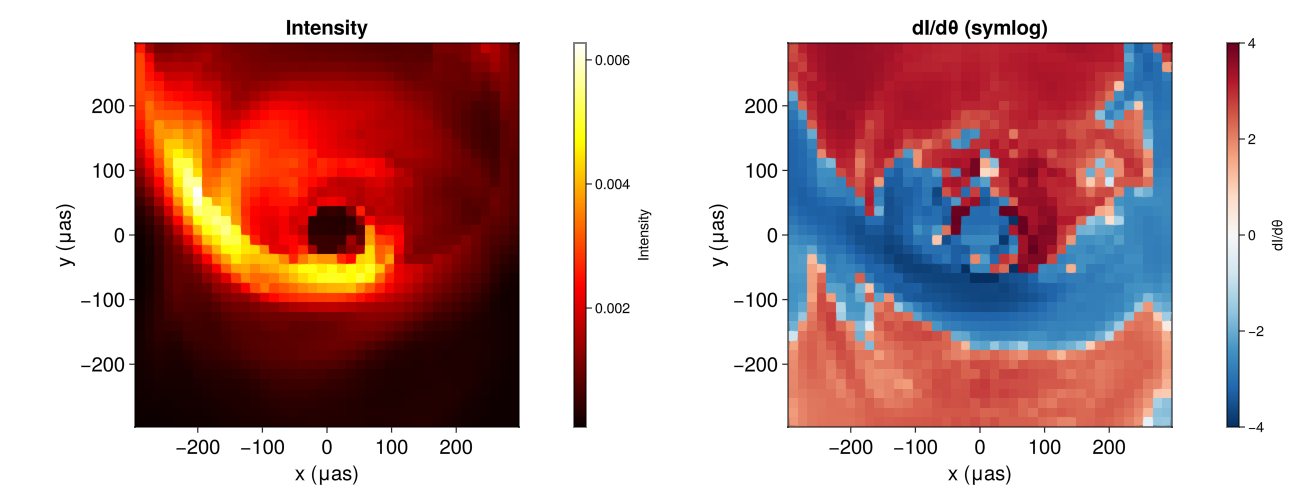

In [23]:
using GLMakie

# Calculate field of view limits
d_kpc = 16900
d_cm = d_kpc * 3.086e21
fov_rg = 160
half_fov_rg = fov_rg / 2

# Angular resolution
theta_rad = (half_fov_rg * L_unit) / d_cm
theta_μas = theta_rad * MUAS_PER_RAD

# Coordinates
x_coords = range(-theta_μas, theta_μas, length=nx)
y_coords = range(-theta_μas, theta_μas, length=ny)

# -----------------------------
# Symlog parameters
# -----------------------------
vmin = -1e-3
vmax =  1e-3
linthresh = 1e-3 * vmax   # = 1e-6

# -----------------------------
# Symlog transform
# -----------------------------
function symlog(x; linthresh)
    absx = abs.(x)
    signx = sign.(x)
    y = similar(x)
    mask = absx .<= linthresh
    y[mask] .= x[mask] ./ linthresh
    y[.!mask] .= signx[.!mask] .* (1 .+ log10.(absx[.!mask] ./ linthresh))
    return y
end

dI_dθ_symlog = symlog(dI_dθo_arr; linthresh=linthresh)

cr_symlog = (
    - (1 + log10(abs(vmin) / linthresh)),
      (1 + log10(abs(vmax) / linthresh))
)

# -----------------------------
# Figure layout (side colorbars)
# -----------------------------
fig = Figure(size = (1300, 500))

# -----------------------------
# Plot 1: Intensity
# -----------------------------
ax1 = Axis(fig[1, 1],
    title = "Intensity",
    xlabel = "x (μas)",
    ylabel = "y (μas)",
    aspect = DataAspect(),
    titlesize  = 20,
    xlabelsize = 20,
    ylabelsize = 20,
    xticklabelsize = 20,
    yticklabelsize = 20
)

hm1 = heatmap!(ax1, x_coords, y_coords, I_arr;
    colormap = :hot
)

Colorbar(fig[1, 2], hm1;
    label = "Intensity"
)

# -----------------------------
# Plot 2: dI/dθ (symlog)
# -----------------------------
ax2 = Axis(fig[1, 3],
    title = "dI/dθ (symlog)",
    xlabel = "x (μas)",
    ylabel = "y (μas)",
    aspect = DataAspect(),
    titlesize  = 20,
    xlabelsize = 20,
    ylabelsize = 20,
    xticklabelsize = 20,
    yticklabelsize = 20
)

hm2 = heatmap!(ax2, x_coords, y_coords, dI_dθ_symlog;
    colormap = Reverse(:RdBu),
    colorrange = cr_symlog
)

Colorbar(fig[1, 4], hm2;
    label = "dI/dθ"
)



fig


In [24]:
dI_dθ_symlog

40×40 Matrix{Float64}:
  1.75609    1.70554   1.78255  1.97883  …   2.92284   2.68229   2.59274
  1.98188    1.98381   2.00995  2.06963      2.73533   2.88592   3.10857
  2.11822    2.12656   2.14596  2.1724       3.23492   3.30058   3.3159
  2.18788    2.16838   2.1562   2.19822      3.40386   3.41498   3.43456
  2.20095    2.20347   2.21484  2.20194      3.48438   3.49791   3.49716
  2.20391    2.2177    2.19897  2.00409  …   3.50475   3.52607   3.53142
  2.19797    2.22241   2.09657  2.15508      3.49914   3.52183   3.52716
  2.27217    2.29256   2.27563  2.41551      3.47575   3.47321   3.50528
  2.38147    2.40617   2.40919  2.19962      3.45192   3.43326   3.46035
  2.43915    2.38421   2.24458  1.88902      3.41249   3.42165   3.38956
  2.42283    2.35154   2.08432  1.99736  …   3.30114   3.3525    3.36736
  2.44373    2.31391   2.12813  2.1617       3.24879   3.23417   3.31252
  2.47296    2.35235   2.19713  1.98907      3.12041   3.18647   3.15972
  ⋮                          

### Parameter Recovery via Conjugate Gradient

In this cell, we use the **conjugate gradient algorithm** to recover the **ground truth black hole spin (`a`)** and **observer inclination (`θ`)** from the computed intensity map (`I_arr`).  

- `initial_spin_guess` and `initial_th_guess` provide the starting point for the optimization.  
- `true_conjugate_gradient_optimization` iteratively adjusts the parameters to minimize the difference between the **ground truth intensity** and the intensity predicted by the current parameter guess.  
- The outputs are:  
  - `ths` → recovered inclination values over iterations  
  - `as` → recovered spin values over iterations  
  - `err` → error at each iteration  
  - `steps` → number of iterations taken  

This procedure demonstrates **gradient-based parameter estimation** using the derivatives computed with autodiff.


In [17]:
#This will run the conjugate gradient
include("../src/main.jl")
spin_value = 0.9375
initial_th_guess = 85.88
ths, as, err, steps = true_conjugate_gradient_optimization(I_arr, ro, initial_th_guess, spin_value, freq, nx, ny, nmaxstep, fovx, fovy, Rout, Rstop; cost_tol = 6e-14, optimize_param = :theta, simulation_data)

Optimization mode: theta
Optimizing θo: true, Optimizing a: false
Running AutoDiffGeoTrajEulerMethod with θo = 85.88, a = 0.9375 and applying σ_pixels = 0.0 filter
  Convergence check: cost=0.00024976700393236325, grad_norm=0.0008464028944910661
  Cost converged: false, Grad converged: false, Stagnant: false
Initial cost: 0.00024976700393236325, Initial θo: 85.88, Initial a: 0.9375
Initial gradient norm: 0.0008464028944910661

--- Iteration 1 ---
Trying aggressive initial step: 354.44113193916604, set at iteration 1
Cost before line search: 0.00024976700393236325
Using cached computation for x = [1.4313333333333333, 1.5625]
grad = [0.0008464028944910661, 0.0], direction = [-0.0008464028944910661, 0.0]
  Line search: f0=0.00024976700393236325, df0=-7.163978598028548e-7, initial_step=354.44113193916604
Running AutoDiffGeoTrajEulerMethod with θo = 67.88, a = 0.9375 and applying σ_pixels = 0.0 filter
  Step 1: step_size=354.44113193916604, f_new=4.547325034631062e-5, improvement=0.00020429

([85.88, 67.88, 58.879999999999995, 60.004999999999995, 60.004999999999995], [0.9375, 0.9375, 0.9375, 0.9375, 0.9375], [0.00024976700393236325, 4.547325034631062e-5, 1.6282195852805264e-6, 4.345162600470706e-9, 4.345162600470706e-9], 200)

Plot theta, spin and error evolution at each iteration step

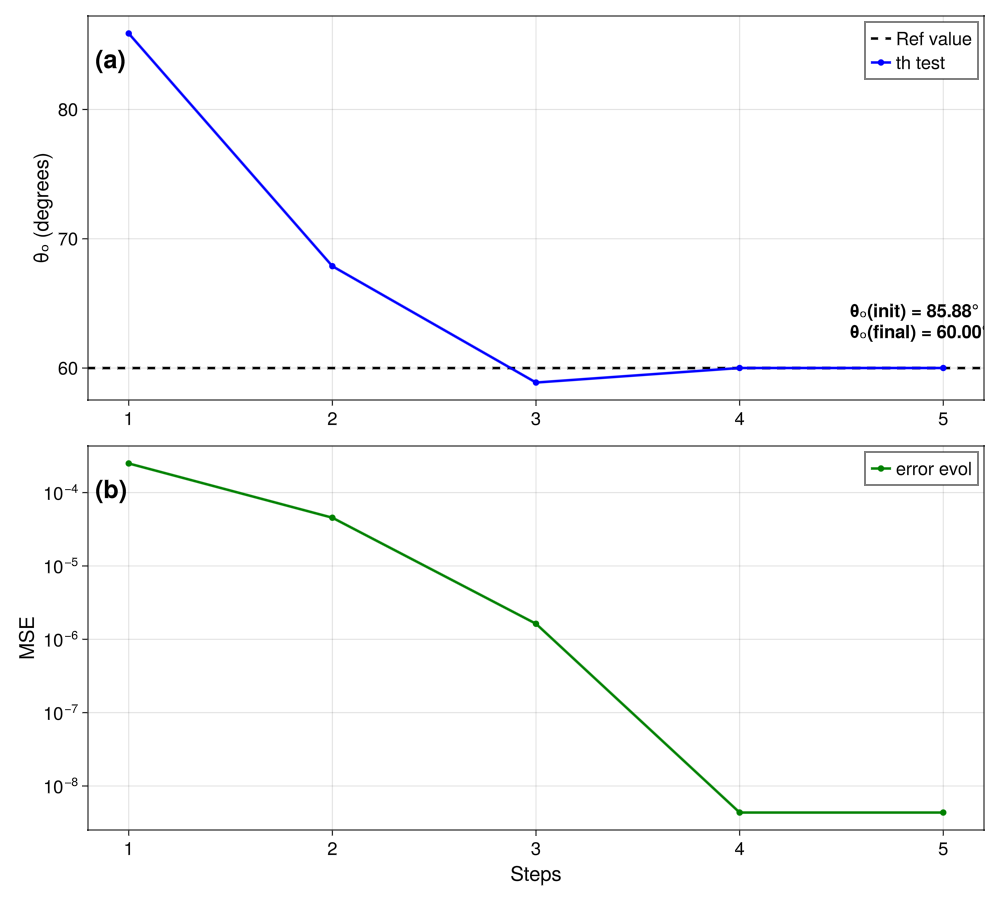

In [18]:
using GLMakie

fig = Figure(size = (1000, 900))
xticks = 0:9  # Custom x-axis ticks

# (a) Plot θₒ
ax1 = Axis(fig[1, 1], 
    ylabel = "θₒ (degrees)",
    ylabelsize = 20, xlabelsize = 20,
    xticklabelsize = 18, yticklabelsize = 18, 
    xticks = xticks
)
hlines!(ax1, 60, color = :black, linestyle = :dash, linewidth = 2.5, label = "Ref value")
scatterlines!(ax1, 1:length(ths), ths, color = :blue, linewidth = 2.5, label = "th test")
axislegend(ax1, position = :rt, labelsize = 18)
text!(ax1, 0.008, 0.85, text = "(a)", space = :relative, fontsize = 25, font = :bold)

# Get initial and final values
θ_init = ths[1]
θ_final = ths[end]

# Format text (rounded for readability)
label_text = @sprintf("θₒ(init) = %.2f°\nθₒ(final) = %.2f°", θ_init, θ_final)

# Add text to first plot (ax1)
text!(
    ax1,
    0.85, 0.15,              # relative position (x, y)
    text = label_text,
    space = :relative,
    fontsize = 18,
    align = (:left, :bottom),
    font = :bold
)

# (b) Plot Error
ax3 = Axis(fig[2, 1],
    xlabel = "Steps", ylabel = "MSE",
    yscale = log10,
    ylabelsize = 20, xlabelsize = 20,
    xticklabelsize = 18, yticklabelsize = 18, 
    xticks = xticks
)
scatterlines!(ax3, 1:length(err), err, color = :green, linewidth = 2.5, label = "error evol")
axislegend(ax3, position = :rt, labelsize = 18)
text!(ax3, 0.008, 0.85, text = "(b)", space = :relative, fontsize = 25, font = :bold)

# Link all x-axes
linkxaxes!(ax1, ax3)

# Display and save
save("../imgs/th_convergence_nonoise_top.png", fig)
fig